# SST bias in CM2.5-FLOR

Code for analyzing the JAS sea surface temperature (SST) bias, relative to observations, in the CM2.5-FLOR Preindustrial control (CTRL) and topography sensitivity experiments (HI$_{gbl}$ and HI$_{mex}$).

In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib import cm

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory

## LOAD DATA

In [18]:
keys=['obs','flor']
obs_prods=['hadisst']   # TODO: name of the SST observational product (e.g., 'hadisst', 'oisst', 'ersst')
flor_runs=['ctrl','hitopo','hicam']   # hitopo = HI_gbl, hicam = HI_mex
files={ 'obs':{}, 'flor':{} }

# TODO: replace placeholder file names
for key in ['obs']:
    files[key]['hadisst'] = f'{dpath0}/obs_data/hadisst.gn.timeseries.1870-2020.nc'
for key in ['flor']:
    for run in flor_runs:
        files[key][run] = f'{dpath0}/FLOR/{run}/pi/flor.{run}.sst.nc'

files['flor']['land_mask'] = f'{dpath0}/FLOR/flor.land_mask.nc'

# variable / coordinate names in the files above
varn = {'obs':'sst', 'flor':'t_surf'}
rename = {'obs'  : {'longitude':'lon', 'latitude':'lat'},
          'flor' : {'grid_xt':'lon',   'grid_yt':'lat'}  }

In [26]:
# domain
latmin, latmax = -20, 70
lonmin, lonmax = 180, 340

# periods (model years and observational years to be compared)
yr_min, yr_max = '0101', '0200'          # FLOR model years
obs_yr_min, obs_yr_max = '1870', '1970'  # observations

def to_degC(da):
    """Convert from K to degC if the data appear to be in K."""
    if float(da.mean()) > 150:
        da = da - 273.15
    da.attrs['units'] = 'degC'
    return da

dat = {'obs':{}, 'flor':{}}

# observations
for prod in obs_prods:
    ds = xr.open_dataset(files['obs'][prod], chunks={})
    ds = ds.rename(rename['obs'])[varn['obs']]
    ds = ds.transpose('time','lat','lon')
    ds = lonFlip(ds)  # -180:180 -> 0:360
    ds = ds.sortby('lat').sel(time=slice(obs_yr_min, obs_yr_max))
    dat['obs'][prod] = to_degC(ds).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))

# FLOR
for run in flor_runs:
    ds = xr.open_dataset(files['flor'][run])[varn['flor']].sel(time=slice(yr_min, yr_max))
    ds = ds.rename(rename['flor'])
    ds['lat'].attrs['units'] = 'degrees_north'
    ds['lon'].attrs['units'] = 'degrees_east'
    dat['flor'][run] = to_degC(ds).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))

land_mask = xr.open_dataset(files['flor']['land_mask'])['LAND_MASK'].sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))

# model grid
lats = dat['flor']['ctrl']['lat']
lons = dat['flor']['ctrl']['lon']

## SEASONAL MEANS

In [27]:
jas_mean = {'obs':{}, 'flor':{}}       # JAS climatology
ann_jas_mean = {'obs':{}, 'flor':{}}   # per-year JAS means (for significance testing)

for key in keys:
    for name, da in dat[key].items():
        jas_mean[key][name] = jas_seasonal_mean(da).load()
        ann_jas_mean[key][name] = jas_yearly_mean(da).load()

# regrid obs to the FLOR grid (area-weighted; cells with <50% valid obs coverage -> NaN)
jas_mean_regrid, ann_jas_mean_regrid = {}, {}
for prod in obs_prods:
    jas_mean_regrid[prod] = conservative_regrid(jas_mean['obs'][prod], lats, lons, min_coverage=0.5)
    ann_jas_mean_regrid[prod] = conservative_regrid(ann_jas_mean['obs'][prod], lats, lons, min_coverage=0.5)

# common ocean mask: model grid points where obs are valid (removes land and sea-ice-masked cells)
ocean_mask = {prod: jas_mean_regrid[prod].notnull() for prod in obs_prods}

## SIGNIFICANCE

In [28]:
# model - obs; Welch's t-test on the per-year JAS means; masked where p > 0.1
obs_diff, obs_diff_mask, obs_ptvals = {}, {}, {}
for prod in obs_prods:
    obs_diff[prod], obs_diff_mask[prod], obs_ptvals[prod] = {}, {}, {}
    for run in flor_runs:
        d, m, p = sigtest2n(ann_jas_mean['flor'][run].where(ocean_mask[prod]),
                            ann_jas_mean_regrid[prod],
                            jas_mean['flor'][run].where(ocean_mask[prod]),
                            jas_mean_regrid[prod])
        obs_diff[prod][run] = d
        obs_diff_mask[prod][run] = m
        obs_ptvals[prod][run] = p

## FIGURES

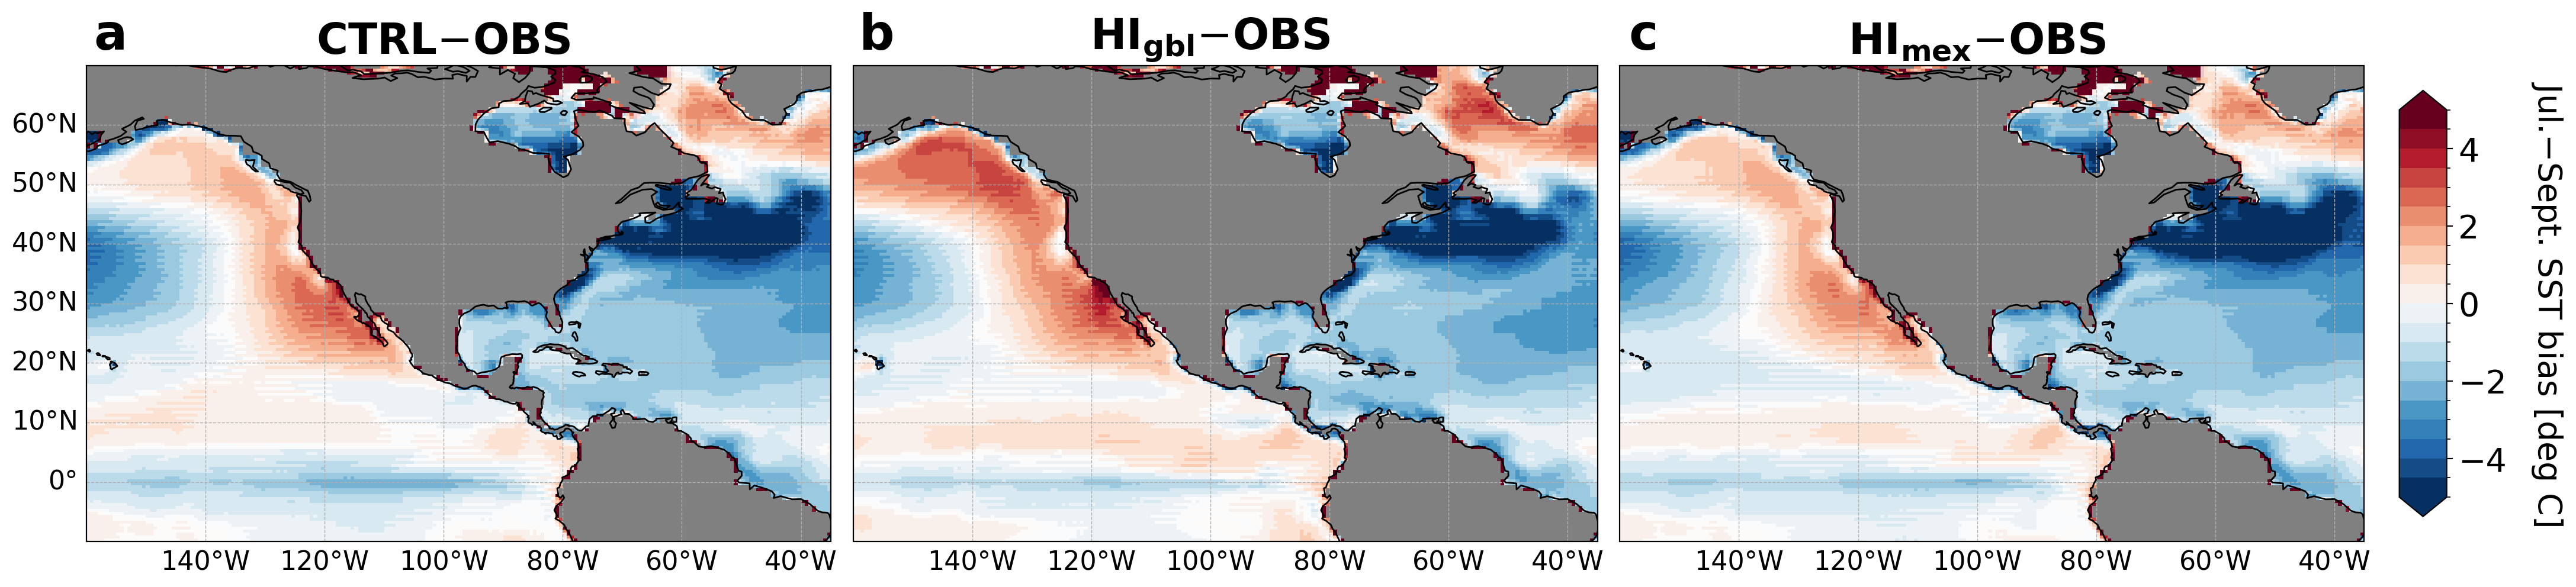

In [37]:
prod = obs_prods[0]

text_kw={'color':'k','weight':'bold','size':26,'ha':'center','va':'bottom'}
text_kw2={'color':'k','weight':'bold','size':30,'ha':'center','va':'bottom'}
titles=np.array(['CTRL$-$OBS', r'HI$_{\mathbf{gbl}}$$-$OBS', r'HI$_{\mathbf{mex}}$$-$OBS'])
letters=['a','b','c']

dcmap,_,_,_=get_settings(field='sst', diff=True)
dlevels=np.linspace(-5, 5, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)

trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree(central_longitude=180)
lon=lons.values
lat=lats.values
tx=(lonmin+lonmax)/2; ty=latmax+0.5

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,6), layout='constrained', subplot_kw={'projection':proj})
for i, run in enumerate(flor_runs):
    # light gray: bias that is not significant (p > 0.1); color: significant bias
    ax[i].pcolormesh(lon, lat, obs_diff[prod][run].where(obs_diff_mask[prod][run].isnull()),
                     cmap=dcmap, norm=dnorm, alpha=0.25, transform=trans, zorder=1)
    cf=ax[i].pcolormesh(lon, lat, obs_diff_mask[prod][run], cmap=dcmap, norm=dnorm, transform=trans, zorder=2)

    # add flor land mask
    land_mask_grey = np.ma.masked_where(land_mask <= 0.8, np.ones_like(land_mask))
    ax[i].pcolormesh(lon, lat, land_mask_grey, cmap=mpl.colors.ListedColormap(['grey']), vmin=0, vmax=1, transform=trans, zorder=2)

    ax[i].coastlines(color='k', linewidth=1, zorder=51)
    ax[i].text(tx, ty, titles[i], transform=trans, **text_kw)
    ax[i].text(lonmin+24, ty+0.5, letters[i], transform=trans, **text_kw2)
    ax[i].set_extent([lonmin+20, lonmax-15, -10, latmax], crs=trans)

    gl=ax[i].gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color':'black','weight':'normal','size':16}
    gl.ylabel_style={'color':'black','weight':'normal','size':16}

cax=fig.add_axes([1.01, 0.2, 0.02, 0.6])
cbar=fig.colorbar(cf, ticks=[-4,-2,0,2,4], orientation='vertical', extend='both', cax=cax)
cbar.set_label('Jul.$-$Sept. SST bias [deg C]', labelpad=35, rotation=270, size=20, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=20)
for tick in cbar.ax.yaxis.get_major_ticks(): tick.label2.set_fontweight('normal')

plt.savefig('../figs/sst_flor_pi_obs-bias.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../figs/sst_flor_pi_obs-bias.png', transparent=False, bbox_inches='tight')